# 🔍 Anomaly Detection — Tournament Analysis

**Objective:** Detect unusual tournaments based on revenue, attendance, viewers, and prize money.

**Business Use Case:**
- Tournament organizers want to identify events that behave unexpectedly
- Sponsors want to spot tournaments with abnormal ROI patterns
- Analysts want to flag outliers before building forecasting models

**Models Used:**
1. **Isolation Forest** — tree-based anomaly detection
2. **Local Outlier Factor (LOF)** — density-based anomaly detection

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('../data/clean_top_tournaments.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (25, 17)


,tournament_id,tournament_name,year,location,total_viewers_millions,peak_viewers_thousands,avg_viewers_thousands,tv_channels,digital_platforms,ticket_revenue_eur,stadium_attendance,stadium_capacity,prize_money_eur,tv_channels_list,digital_platforms_list,tv_channels_count,occupancy_rate
0,WPT001,World Padel Tour Master Final,2023,Barcelona,12.5,2100,850,Eurosport;Movistar+,WPT TV;YouTube,2100000,16500,17000,500000,"['Eurosport', 'Movistar+']","['WPT TV', 'YouTube']",2,97.06
1,WPT002,Madrid Master,2024,Madrid,9.8,1800,720,DAZN;TVE,WPT TV,1850000,14200,15000,450000,"['DAZN', 'TVE']",['WPT TV'],2,94.67
2,PPT001,Premier Padel Riyadh,2024,Riyadh,15.2,2800,1100,beIN Sports,WPT TV;YouTube,3200000,19800,20000,750000,['beIN Sports'],"['WPT TV', 'YouTube']",1,99.00
3,WPT003,Estrella Damm Master,2023,Valencia,8.3,1500,650,Movistar+,YouTube,1650000,12500,13500,350000,['Movistar+'],['YouTube'],1,92.59
4,PPT002,Premier Padel Mexico,2023,Mexico City,11.3,2200,890,ESPN,WPT TV,1950000,15800,16500,600000,['ESPN'],['WPT TV'],1,95.76


In [3]:
df.describe().round(2)

,year,total_viewers_millions,peak_viewers_thousands,avg_viewers_thousands,ticket_revenue_eur,stadium_attendance,stadium_capacity,prize_money_eur,tv_channels_count,occupancy_rate
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,2023.48,8.36,1498.80,655.60,1576800.00,12212.00,13080.00,406400.00,1.32,92.65
std,0.51,2.68,518.56,170.93,572718.08,3705.55,3590.15,163958.33,0.48,3.24
min,2023.00,4.90,820.00,410.00,780000.00,6900.00,8000.00,200000.00,1.00,86.25
25%,2023.00,6.50,1100.00,540.00,1150000.00,9200.00,10000.00,270000.00,1.00,90.00
50%,2023.00,7.90,1420.00,650.00,1450000.00,11400.00,12000.00,350000.00,1.00,92.59
75%,2024.00,9.70,1800.00,720.00,1900000.00,15100.00,16000.00,520000.00,2.00,95.00
max,2024.00,15.20,2800.00,1100.00,3200000.00,19800.00,20000.00,750000.00,2.00,99.00


In [4]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
tournament_id             0
tournament_name           0
year                      0
location                  0
total_viewers_millions    0
peak_viewers_thousands    0
avg_viewers_thousands     0
tv_channels               0
digital_platforms         0
ticket_revenue_eur        0
stadium_attendance        0
stadium_capacity          0
prize_money_eur           0
tv_channels_list          0
digital_platforms_list    0
tv_channels_count         0
occupancy_rate            0
dtype: int64


## 3. Feature Engineering & Selection

We select numerical features that best describe tournament performance.
All features are scaled using **StandardScaler** to prevent features with large ranges (e.g. revenue in millions) from dominating the distance calculations.

In [5]:
features = [
    'ticket_revenue_eur',
    'stadium_attendance',
    'total_viewers_millions',
    'prize_money_eur',
    'occupancy_rate'
]

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print('Features selected:', features)
print(f'\nScaled data shape: {X_scaled_df.shape}')
X_scaled_df.describe().round(3)

Features selected: ['ticket_revenue_eur', 'stadium_attendance', 'total_viewers_millions', 'prize_money_eur', 'occupancy_rate']

Scaled data shape: (25, 5)


,ticket_revenue_eur,stadium_attendance,total_viewers_millions,prize_money_eur,occupancy_rate
count,25.000,25.000,25.000,25.000,25.000
mean,0.000,-0.000,-0.000,-0.000,-0.000
std,1.021,1.021,1.021,1.021,1.021
min,-1.420,-1.463,-1.319,-1.285,-2.015
25%,-0.761,-0.830,-0.710,-0.849,-0.835
50%,-0.226,-0.224,-0.177,-0.351,-0.020
75%,0.576,0.795,0.509,0.707,0.738
max,2.893,2.090,2.603,2.139,1.997


### Feature Correlation Heatmap
Before running anomaly detection, let's understand how features relate to each other.

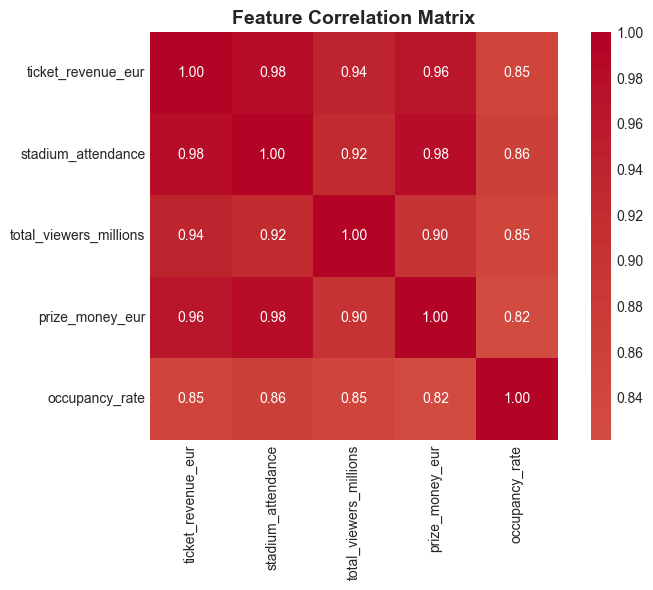

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    X.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Model 1 — Isolation Forest

### 4.1 Intuition & Theory

**Isolation Forest** works on a simple principle: *anomalies are easier to isolate than normal points.*

- It builds many random decision trees by repeatedly splitting the data on random features and random split values
- For each point, it measures how many splits (path length) are needed to isolate it
- **Anomalies** = isolated quickly = **short path length**
- **Normal points** = require many splits = **long path length**

**Key Parameters:**
- `n_estimators`: number of trees (default 100)
- `contamination`: expected proportion of anomalies
- `max_samples`: number of samples to draw per tree

**Assumptions:**
- Anomalies are rare in the dataset
- Anomalies are numerically different from normal observations

**Limitations:**
- Struggles when anomalies cluster together
- Sensitive to `contamination` parameter choice
- Does not work well with very high-dimensional data

In [7]:
CONTAMINATION = 0.10  # We expect ~10% of tournaments to be anomalous

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=CONTAMINATION,
    random_state=42
)

df['iso_pred'] = iso_forest.fit_predict(X_scaled)
df['iso_score'] = iso_forest.decision_function(X_scaled)
df['iso_label'] = df['iso_pred'].map({1: 'Normal', -1: 'Anomaly'})

print('Isolation Forest Results:')
print(df['iso_label'].value_counts())
print(f'\nAnomaly rate: {(df["iso_pred"]==-1).mean()*100:.1f}%')

Isolation Forest Results:
iso_label
Normal     22
Anomaly     3
Name: count, dtype: int64

Anomaly rate: 12.0%


### 4.2 Isolation Forest — Anomaly Score Distribution

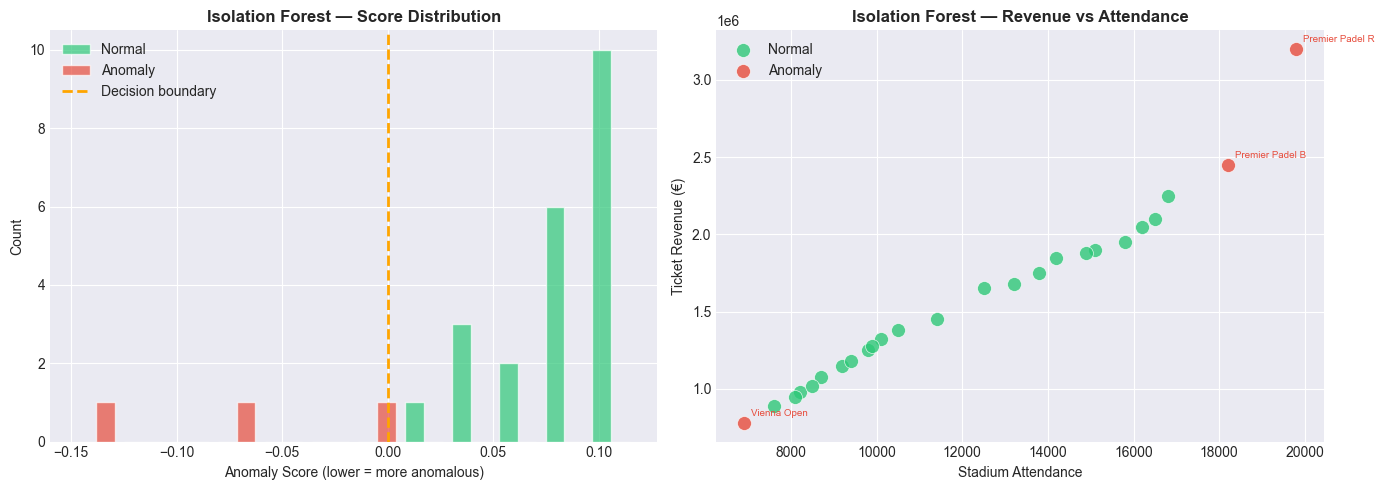

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
colors = df['iso_label'].map({'Normal': '#2EC878', 'Anomaly': '#E74C3C'})
axes[0].hist(
    [df[df['iso_label']=='Normal']['iso_score'],
     df[df['iso_label']=='Anomaly']['iso_score']],
    bins=12, label=['Normal', 'Anomaly'],
    color=['#2EC878', '#E74C3C'], alpha=0.7, edgecolor='white'
)
axes[0].axvline(0, color='orange', linestyle='--', linewidth=2, label='Decision boundary')
axes[0].set_title('Isolation Forest — Score Distribution', fontweight='bold')
axes[0].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Scatter: Revenue vs Attendance
for label, color in [('Normal', '#2EC878'), ('Anomaly', '#E74C3C')]:
    mask = df['iso_label'] == label
    axes[1].scatter(
        df[mask]['stadium_attendance'],
        df[mask]['ticket_revenue_eur'],
        c=color, label=label, s=100, alpha=0.8, edgecolors='white', linewidth=0.5
    )

# Annotate anomalies
for _, row in df[df['iso_label']=='Anomaly'].iterrows():
    axes[1].annotate(
        row['tournament_name'][:15],
        (row['stadium_attendance'], row['ticket_revenue_eur']),
        textcoords='offset points', xytext=(5, 5), fontsize=7, color='#E74C3C'
    )

axes[1].set_title('Isolation Forest — Revenue vs Attendance', fontweight='bold')
axes[1].set_xlabel('Stadium Attendance')
axes[1].set_ylabel('Ticket Revenue (€)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Model 2 — Local Outlier Factor (LOF)

### 5.1 Intuition & Theory

**Local Outlier Factor** detects anomalies by comparing the **local density** of a point to the density of its neighbors.

- For each point, it finds its k nearest neighbors
- It computes the **reachability distance** to those neighbors
- It compares the local density of the point to the average density of its neighbors
- **LOF score ≈ 1** → similar density to neighbors → **Normal**
- **LOF score >> 1** → much lower density than neighbors → **Anomaly**

**Key Parameters:**
- `n_neighbors`: number of neighbors to consider (typically 5–20)
- `contamination`: expected proportion of anomalies

**Assumptions:**
- Normal points live in dense, well-defined regions
- Anomalies exist in sparse, isolated regions

**Limitations:**
- Computationally slower than Isolation Forest on large datasets
- Results are sensitive to `n_neighbors` choice
- Does not generalize to new data (transductive, not inductive)

In [9]:
N_NEIGHBORS = 5

lof = LocalOutlierFactor(
    n_neighbors=N_NEIGHBORS,
    contamination=CONTAMINATION
)

df['lof_pred'] = lof.fit_predict(X_scaled)
df['lof_score'] = lof.negative_outlier_factor_
df['lof_label'] = df['lof_pred'].map({1: 'Normal', -1: 'Anomaly'})

print('Local Outlier Factor Results:')
print(df['lof_label'].value_counts())
print(f'\nAnomaly rate: {(df["lof_pred"]==-1).mean()*100:.1f}%')

Local Outlier Factor Results:
lof_label
Normal     22
Anomaly     3
Name: count, dtype: int64

Anomaly rate: 12.0%


### 5.2 LOF — Anomaly Score Distribution

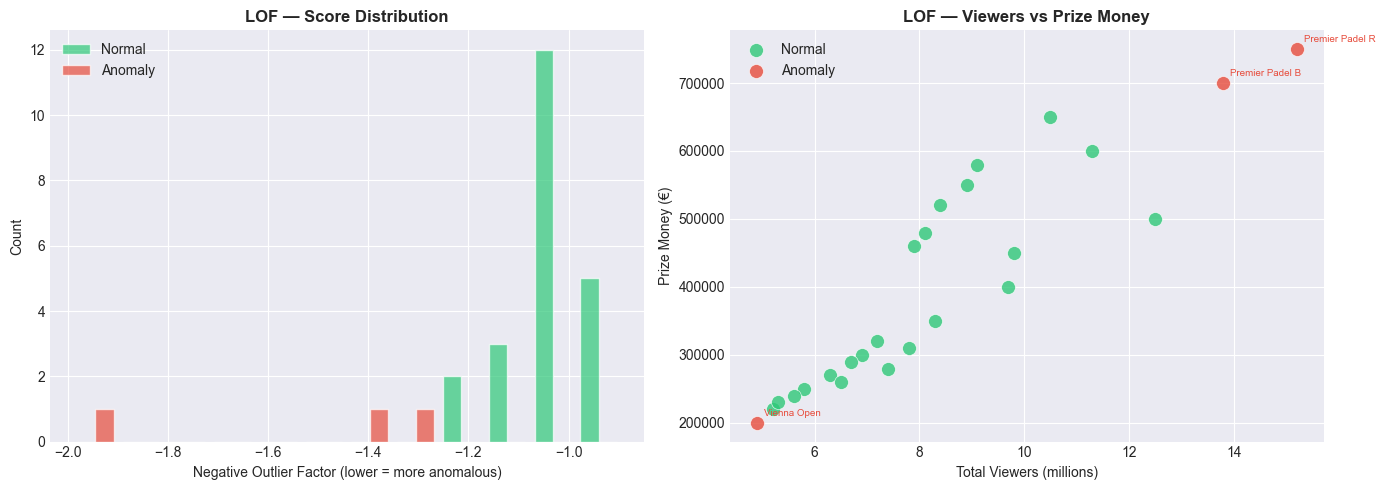

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(
    [df[df['lof_label']=='Normal']['lof_score'],
     df[df['lof_label']=='Anomaly']['lof_score']],
    bins=12, label=['Normal', 'Anomaly'],
    color=['#2EC878', '#E74C3C'], alpha=0.7, edgecolor='white'
)
axes[0].set_title('LOF — Score Distribution', fontweight='bold')
axes[0].set_xlabel('Negative Outlier Factor (lower = more anomalous)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Scatter: Viewers vs Prize Money
for label, color in [('Normal', '#2EC878'), ('Anomaly', '#E74C3C')]:
    mask = df['lof_label'] == label
    axes[1].scatter(
        df[mask]['total_viewers_millions'],
        df[mask]['prize_money_eur'],
        c=color, label=label, s=100, alpha=0.8, edgecolors='white', linewidth=0.5
    )

for _, row in df[df['lof_label']=='Anomaly'].iterrows():
    axes[1].annotate(
        row['tournament_name'][:15],
        (row['total_viewers_millions'], row['prize_money_eur']),
        textcoords='offset points', xytext=(5, 5), fontsize=7, color='#E74C3C'
    )

axes[1].set_title('LOF — Viewers vs Prize Money', fontweight='bold')
axes[1].set_xlabel('Total Viewers (millions)')
axes[1].set_ylabel('Prize Money (€)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. PCA Visualization (2D)

Since we have 5 features, we use **PCA** to reduce to 2 dimensions for visualization while preserving the most variance.

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

Variance explained by PC1: 92.6%
Variance explained by PC2: 4.4%
Total variance explained: 97.0%


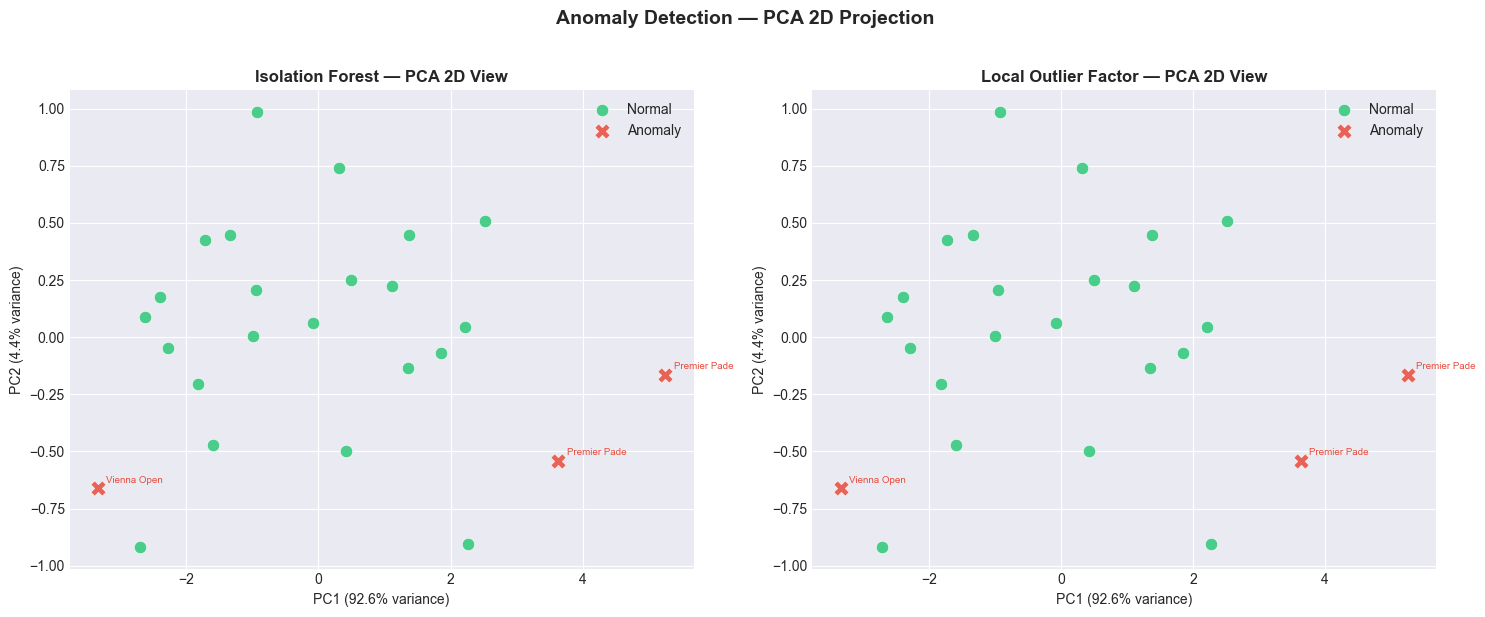

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

titles = ['Isolation Forest', 'Local Outlier Factor']
label_cols = ['iso_label', 'lof_label']

for ax, title, label_col in zip(axes, titles, label_cols):
    for label, color, marker in [('Normal', '#2EC878', 'o'), ('Anomaly', '#E74C3C', 'X')]:
        mask = df[label_col] == label
        ax.scatter(
            df[mask]['pca1'], df[mask]['pca2'],
            c=color, label=label, s=120 if label=='Anomaly' else 80,
            marker=marker, alpha=0.85, edgecolors='white', linewidth=0.5
        )
    for _, row in df[df[label_col]=='Anomaly'].iterrows():
        ax.annotate(
            row['tournament_name'][:12],
            (row['pca1'], row['pca2']),
            textcoords='offset points', xytext=(6, 4), fontsize=7, color='#E74C3C'
        )
    ax.set_title(f'{title} — PCA 2D View', fontweight='bold', fontsize=12)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax.legend()

plt.suptitle('Anomaly Detection — PCA 2D Projection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Model Comparison & Evaluation

Since anomaly detection is **unsupervised** (no ground truth labels), we compare models using:
- **Agreement rate** between the two models
- **Score separation** between normal and anomalous points
- **Business interpretability** of flagged anomalies

In [15]:
# Agreement analysis
df['consensus'] = df.apply(
    lambda r: 'Both: Anomaly' if r['iso_pred']==-1 and r['lof_pred']==-1
    else ('Both: Normal' if r['iso_pred']==1 and r['lof_pred']==1
          else 'Models Disagree'), axis=1
)

agreement_rate = (df['iso_pred'] == df['lof_pred']).mean() * 100

iso_anom    = (df['iso_pred'] == -1).sum()
lof_anom    = (df['lof_pred'] == -1).sum()
iso_normal  = (df['iso_pred'] == 1).sum()
lof_normal  = (df['lof_pred'] == 1).sum()
iso_rate    = (df['iso_pred'] == -1).mean() * 100
lof_rate    = (df['lof_pred'] == -1).mean() * 100
iso_avg_a   = df[df['iso_pred'] == -1]['iso_score'].mean()
lof_avg_a   = df[df['lof_pred'] == -1]['lof_score'].mean()
iso_avg_n   = df[df['iso_pred'] == 1]['iso_score'].mean()
lof_avg_n   = df[df['lof_pred'] == 1]['lof_score'].mean()
consensus_anom = (df['consensus'] == 'Both: Anomaly').sum()
disagree    = (df['consensus'] == 'Models Disagree').sum()

print('=' * 65)
print('MODEL COMPARISON SUMMARY')
print('=' * 65)
print(f"\n{'Metric':<35} {'Isolation Forest':>18} {'LOF':>10}")
print('-' * 65)
print(f"{'Anomalies detected':<35} {iso_anom:>18} {lof_anom:>10}")
print(f"{'Normal points':<35} {iso_normal:>18} {lof_normal:>10}")
print(f"{'Anomaly rate (%)':<35} {iso_rate:>17.1f}% {lof_rate:>9.1f}%")
print(f"{'Avg score (anomalies)':<35} {iso_avg_a:>18.4f} {lof_avg_a:>10.4f}")
print(f"{'Avg score (normal)':<35} {iso_avg_n:>18.4f} {lof_avg_n:>10.4f}")
print('-' * 65)
print(f'\nModel agreement rate: {agreement_rate:.1f}%')
print(f'Consensus anomalies (both models): {consensus_anom}')
print(f'Models disagree on: {disagree} tournament(s)')

MODEL COMPARISON SUMMARY

Metric                                Isolation Forest        LOF
-----------------------------------------------------------------
Anomalies detected                                   3          3
Normal points                                       22         22
Anomaly rate (%)                                 12.0%      12.0%
Avg score (anomalies)                          -0.0778    -1.5437
Avg score (normal)                              0.0844    -1.0355
-----------------------------------------------------------------

Model agreement rate: 100.0%
Consensus anomalies (both models): 3
Models disagree on: 0 tournament(s)


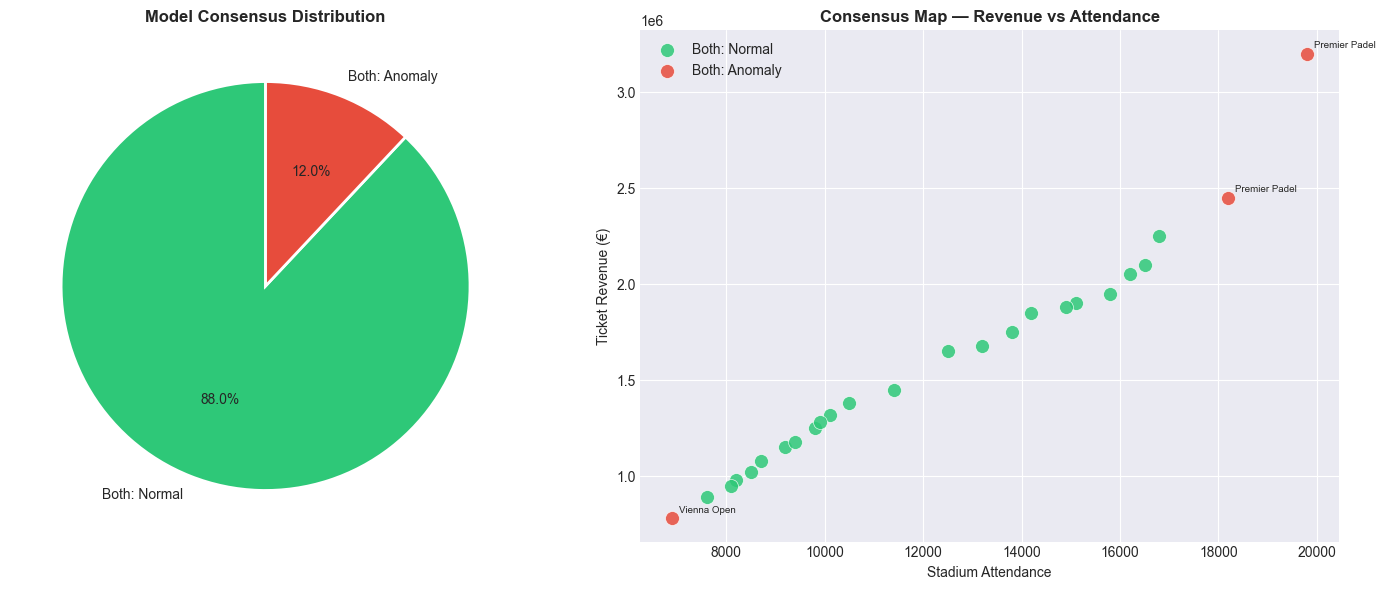

In [16]:
# Consensus visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart of consensus
consensus_counts = df['consensus'].value_counts()
colors_pie = ['#2EC878', '#E74C3C', '#F39C12']
axes[0].pie(
    consensus_counts.values,
    labels=consensus_counts.index,
    colors=colors_pie[:len(consensus_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Model Consensus Distribution', fontweight='bold')

# Consensus scatter
color_map = {'Both: Normal': '#2EC878', 'Both: Anomaly': '#E74C3C', 'Models Disagree': '#F39C12'}
for label, color in color_map.items():
    mask = df['consensus'] == label
    if mask.sum() > 0:
        axes[1].scatter(
            df[mask]['stadium_attendance'],
            df[mask]['ticket_revenue_eur'],
            c=color, label=label, s=100, alpha=0.85,
            edgecolors='white', linewidth=0.5
        )

for _, row in df[df['consensus']!='Both: Normal'].iterrows():
    axes[1].annotate(
        row['tournament_name'][:14],
        (row['stadium_attendance'], row['ticket_revenue_eur']),
        textcoords='offset points', xytext=(5, 4), fontsize=7
    )

axes[1].set_title('Consensus Map — Revenue vs Attendance', fontweight='bold')
axes[1].set_xlabel('Stadium Attendance')
axes[1].set_ylabel('Ticket Revenue (€)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Detected Anomalies — Deep Dive

In [17]:
display_cols = [
    'tournament_name', 'location', 'year',
    'ticket_revenue_eur', 'stadium_attendance',
    'total_viewers_millions', 'prize_money_eur',
    'occupancy_rate', 'iso_label', 'lof_label', 'consensus'
]

print('=== CONSENSUS ANOMALIES (Both Models Agree) ===')
consensus_anom = df[df['consensus']=='Both: Anomaly'][display_cols]
display(consensus_anom)

print('\n=== ISOLATION FOREST ONLY ANOMALIES ===')
iso_only = df[(df['iso_pred']==-1) & (df['lof_pred']==1)][display_cols]
display(iso_only)

print('\n=== LOF ONLY ANOMALIES ===')
lof_only = df[(df['lof_pred']==-1) & (df['iso_pred']==1)][display_cols]
display(lof_only)

=== CONSENSUS ANOMALIES (Both Models Agree) ===


,tournament_name,location,year,ticket_revenue_eur,stadium_attendance,total_viewers_millions,prize_money_eur,occupancy_rate,iso_label,lof_label,consensus
2,Premier Padel Riyadh,Riyadh,2024,3200000,19800,15.2,750000,99.00,Anomaly,Anomaly,Both: Anomaly
14,Premier Padel Buenos Aires,Buenos Aires,2023,2450000,18200,13.8,700000,95.79,Anomaly,Anomaly,Both: Anomaly
19,Vienna Open,Vienna,2023,780000,6900,4.9,200000,86.25,Anomaly,Anomaly,Both: Anomaly



=== ISOLATION FOREST ONLY ANOMALIES ===


,tournament_name,location,year,ticket_revenue_eur,stadium_attendance,total_viewers_millions,prize_money_eur,occupancy_rate,iso_label,lof_label,consensus



=== LOF ONLY ANOMALIES ===


,tournament_name,location,year,ticket_revenue_eur,stadium_attendance,total_viewers_millions,prize_money_eur,occupancy_rate,iso_label,lof_label,consensus


## 9. Feature Importance — What Drives Anomalies?

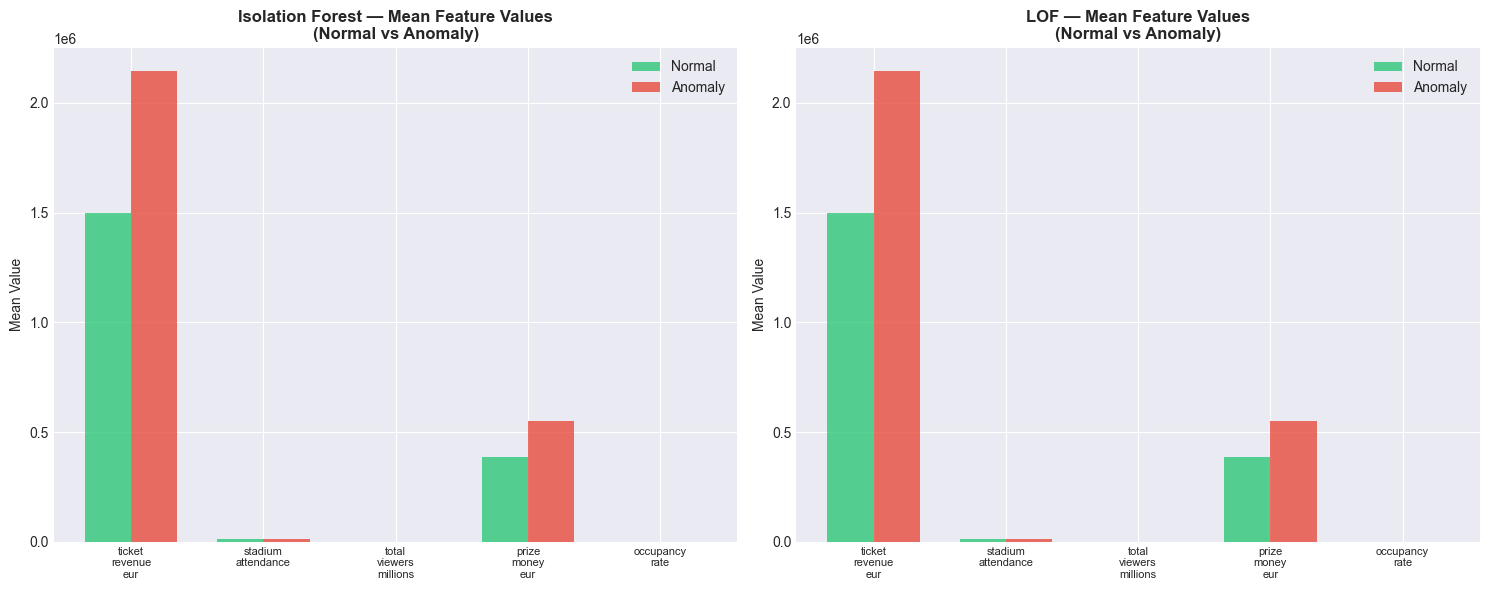

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, label_col, title in zip(
    axes,
    ['iso_label', 'lof_label'],
    ['Isolation Forest', 'LOF']
):
    normal_means = df[df[label_col]=='Normal'][features].mean()
    anomaly_means = df[df[label_col]=='Anomaly'][features].mean()

    x = np.arange(len(features))
    width = 0.35
    bars1 = ax.bar(x - width/2, normal_means, width, label='Normal', color='#2EC878', alpha=0.8)
    bars2 = ax.bar(x + width/2, anomaly_means, width, label='Anomaly', color='#E74C3C', alpha=0.8)

    ax.set_title(f'{title} — Mean Feature Values\n(Normal vs Anomaly)', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f.replace('_', '\n') for f in features], fontsize=8)
    ax.legend()
    ax.set_ylabel('Mean Value')

plt.tight_layout()
plt.show()

## 10. Business Insights & Conclusions

### Key Findings

In [19]:
print('=' * 60)
print('ANOMALY DETECTION — BUSINESS INSIGHTS')
print('=' * 60)

print(f'\n📊 Dataset: {len(df)} professional padel tournaments')
print(f'📌 Features analyzed: {len(features)}')
print(f'\n🔴 Isolation Forest flagged: {(df["iso_pred"]==-1).sum()} anomalies')
print(f'🔴 LOF flagged:               {(df["lof_pred"]==-1).sum()} anomalies')
print(f'✅ Both models agree on:      {(df["consensus"]=="Both: Anomaly").sum()} anomalies (high confidence)')
print(f'⚠️  Models disagree on:        {(df["consensus"]=="Models Disagree").sum()} cases')

print('\n📋 INTERPRETATION GUIDE:')
print('-' * 60)
print('High revenue + low attendance  → Premium/VIP event, investigate pricing')
print('High attendance + low revenue  → Underpriced tickets, revenue leak')
print('Low viewers + high attendance  → Regional event, poor broadcast deal')
print('Both agree = Anomaly           → High confidence, prioritize for review')
print('Models disagree                → Borderline case, needs expert review')

print('\n🏆 RECOMMENDATION:')
print('Focus on consensus anomalies first — these are the most reliable')
print('detections and represent the strongest business opportunities.')

ANOMALY DETECTION — BUSINESS INSIGHTS

📊 Dataset: 25 professional padel tournaments
📌 Features analyzed: 5

🔴 Isolation Forest flagged: 3 anomalies
🔴 LOF flagged:               3 anomalies
✅ Both models agree on:      3 anomalies (high confidence)
⚠️  Models disagree on:        0 cases

📋 INTERPRETATION GUIDE:
------------------------------------------------------------
High revenue + low attendance  → Premium/VIP event, investigate pricing
High attendance + low revenue  → Underpriced tickets, revenue leak
Low viewers + high attendance  → Regional event, poor broadcast deal
Both agree = Anomaly           → High confidence, prioritize for review
Models disagree                → Borderline case, needs expert review

🏆 RECOMMENDATION:
Focus on consensus anomalies first — these are the most reliable
detections and represent the strongest business opportunities.


## 11. Save Results

In [20]:
output_cols = [
    'tournament_name', 'location', 'year',
    'ticket_revenue_eur', 'stadium_attendance',
    'total_viewers_millions', 'prize_money_eur', 'occupancy_rate',
    'iso_label', 'iso_score', 'lof_label', 'lof_score', 'consensus'
]

df[output_cols].to_csv('../data/anomaly_results_tournaments.csv', index=False)
print('Results saved to data/anomaly_results_tournaments.csv ✅')
print(f'Total rows: {len(df)}')

Results saved to data/anomaly_results_tournaments.csv ✅
Total rows: 25
